<a href="https://colab.research.google.com/github/muchammadwr/bank-segmentation-customers/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Transaction Segmentation

## 1. Business Understanding

### 1.1 Latar Belakang

Data transaksi perbankan memuat informasi mengenai karakteristik nasabah dan aktivitas transaksinya, seperti usia, pekerjaan, nilai transaksi, channel, durasi transaksi, dan saldo rekening. Informasi tersebut dapat digunakan untuk mengeksplorasi kelompok transaksi yang memiliki karakteristik serupa.

Proyek ini dikembangkan dari tugas machine learning Dicoding yang menggabungkan clustering dan classification. KMeans digunakan untuk menghasilkan label cluster, kemudian Decision Tree dilatih untuk memprediksi label tersebut. Sebagai pengembangan mandiri, model diintegrasikan ke dalam prototipe Streamlit agar pengguna dapat mencoba prediksi melalui formulir input.

### 1.2 Tujuan Proyek

1. Mengidentifikasi kelompok transaksi berdasarkan kemiripan fitur menggunakan KMeans.
2. Menjelaskan karakteristik setiap cluster berdasarkan hasil analisis.
3. Melatih Decision Tree untuk memprediksi label cluster yang dihasilkan KMeans.
4. Menggunakan Pipeline agar preprocessing saat training dan prediksi tetap konsisten.
5. Mengembangkan prototipe Streamlit dengan tab clustering dan classification.

### 1.3 Pertanyaan Utama

* Bagaimana karakteristik dan distribusi data transaksi dalam dataset?
* Kelompok transaksi apa yang terbentuk melalui KMeans?
* Fitur apa yang membedakan masing-masing cluster?
* Seberapa baik Decision Tree memprediksi label KMeans?
* Bagaimana model dapat digunakan untuk memproses input baru melalui Streamlit?

### 1.4 Kriteria Keberhasilan

* Pipeline mampu memproses fitur numerik dan kategorikal secara konsisten.
* Kualitas clustering dievaluasi menggunakan metrik yang sesuai, distribusi anggota, dan interpretasi karakteristik cluster.
* Performa classification dilaporkan menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.
* Pipeline yang disimpan dan dimuat ulang menghasilkan prediksi yang sama.
* Prototipe Streamlit mampu menerima input pengguna dan menampilkan hasil prediksi.

### 1.5 Ruang Lingkup dan Batasan

Proyek ini merupakan prototipe pembelajaran, bukan sistem operasional bank atau fraud detection. Label `Target` berasal dari KMeans, bukan label bisnis yang diverifikasi oleh bank. Oleh karena itu, evaluasi Decision Tree menunjukkan kemampuannya meniru segmentasi KMeans.

Unit analisis mengikuti baris transaksi pada dataset. Kelompok yang terbentuk tidak otomatis mewakili persona nasabah secara menyeluruh, dan manfaat bisnisnya memerlukan validasi lebih lanjut.


okey, next
## 2. Data Understanding

Tahap ini bertujuan memahami struktur, kualitas, dan karakteristik awal dataset transaksi perbankan. Hasil pemeriksaan digunakan sebagai dasar untuk menentukan fitur dan kebutuhan preprocessing.

### Data Loading


In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

display(df.head())

print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

df.info()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


Jumlah baris: 2537
Jumlah kolom: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   f

In [93]:
numerical_columns = [
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance",
]

categorical_columns = [
    "TransactionType",
    "Location",
    "Channel",
    "CustomerOccupation",
]

### Data Quality Assessment


#### 1. Ringkasan kualitas setiap kolom

In [94]:
quality_summary = pd.DataFrame({
    "DataType": df.dtypes.astype(str),
    "MissingCount": df.isna().sum(),
    "MissingPercent": df.isna().mean().mul(100).round(2),
    "UniqueCount": df.nunique(),
})

display(quality_summary)

,DataType,MissingCount,MissingPercent,UniqueCount
TransactionID,object,29,1.14,2484
AccountID,object,21,0.83,495
TransactionAmount,float64,26,1.02,2433
PreviousTransactionDate,object,28,1.10,2485
TransactionType,object,30,1.18,2
Location,object,30,1.18,43
DeviceID,object,30,1.18,681
IP Address,object,20,0.79,591
MerchantID,object,23,0.91,100
Channel,object,27,1.06,3


#### 2. Pemeriksaan duplikasi

In [95]:
print("Jumlah baris duplikat:", df.duplicated().sum())

display(
    df.loc[df.duplicated(keep=False)].head(10)
)

Jumlah baris duplikat: 21


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
25,TX000026,AC00041,7.49,2023-10-20 17:53:13,Credit,Houston,D000671,81.248.235.147,M043,Online,65.0,Retired,276.0,1.0,3634.67,2024-11-04 8:09:44
103,TX000104,AC00464,196.16,2023-02-24 16:29:23,Debit,Virginia Beach,D000164,204.34.243.93,M099,Branch,27.0,Engineer,146.0,1.0,9418.86,2024-11-04 8:08:32
146,TX000147,AC00385,973.39,2023-08-30 17:23:20,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,77.0,Retired,296.0,1.0,2042.22,2024-11-04 8:11:44
199,TX000200,AC00358,493.11,2023-07-31 16:25:26,Debit,Colorado Springs,D000232,35.220.238.127,M022,Branch,53.0,Retired,236.0,1.0,7432.99,2024-11-04 8:08:01
280,TX000281,AC00133,255.04,2023-11-23 16:15:59,Debit,Seattle,D000206,98.39.212.221,M084,ATM,45.0,Engineer,152.0,1.0,6217.86,2024-11-04 8:11:38
295,TX000296,AC00272,20.54,2023-08-21 18:09:24,Debit,Fort Worth,D000348,171.101.134.74,M055,Branch,51.0,Engineer,72.0,1.0,5327.03,2024-11-04 8:07:28
883,TX000884,AC00448,183.32,2023-05-10 16:27:51,Debit,Raleigh,D000450,162.207.77.170,M041,ATM,21.0,Student,74.0,1.0,137.42,2024-11-04 8:09:31
913,TX000914,AC00386,254.21,2023-05-22 16:48:08,Debit,Phoenix,D000487,137.33.78.168,M030,ATM,48.0,Engineer,46.0,1.0,2487.20,2024-11-04 8:10:50
935,TX000936,AC00320,20.64,2023-04-20 16:01:05,Debit,Charlotte,D000063,197.23.128.119,M079,Branch,22.0,Student,59.0,1.0,949.38,2024-11-04 8:09:17
985,TX000986,AC00278,121.17,2023-12-25 17:31:16,Debit,Phoenix,D000573,155.19.119.0,M053,ATM,68.0,Doctor,158.0,1.0,12990.77,2024-11-04 8:10:12


In [96]:
if "TransactionID" in df.columns:
    print(
        "Jumlah ID transaksi berulang:",
        df["TransactionID"].duplicated().sum(),
    )

Jumlah ID transaksi berulang: 52


#### 3. Pemeriksaan kategori

In [97]:
for column in categorical_columns:
    print(f"\nKategori pada {column}:")
    print(df[column].value_counts(dropna=False))


Kategori pada TransactionType:
TransactionType
Debit     1942
Credit     565
NaN         30
Name: count, dtype: int64

Kategori pada Location:
Location
Fort Worth          71
Oklahoma City       69
Los Angeles         69
Charlotte           68
Tucson              68
Philadelphia        67
Miami               65
Houston             65
Memphis             64
Omaha               63
Detroit             63
Denver              62
Boston              61
Seattle             61
New York            60
Chicago             60
Raleigh             60
Mesa                60
Atlanta             60
Colorado Springs    60
Fresno              59
San Antonio         59
Jacksonville        59
Austin              59
San Jose            59
Kansas City         58
Phoenix             58
Indianapolis        58
San Diego           57
San Francisco       57
Virginia Beach      56
Las Vegas           55
Sacramento          54
Nashville           54
Columbus            54
Milwaukee           54
Baltimore          

In [99]:
review_columns = [
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "LoginAttempts",
]

display(
    df[review_columns]
    .lt(0)
    .sum()
    .rename("NegativeCount")
    .to_frame()
)

,NegativeCount
TransactionAmount,0
CustomerAge,0
TransactionDuration,0
LoginAttempts,0


#### 4. Pemeriksaan nilai numerik dan fitur konstan

In [98]:
display(df[numerical_columns].describe().T)

constant_columns = [
    column
    for column in numerical_columns + categorical_columns
    if df[column].nunique(dropna=True) <= 1
]

print("Kolom konstan atau seluruhnya kosong:", constant_columns)

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2511.0,297.656468,292.230367,0.26,81.3100,211.36,413.1050,1919.11
CustomerAge,2519.0,44.678444,17.837359,18.00,27.0000,45.00,59.0000,80.00
TransactionDuration,2511.0,119.422939,70.078513,10.00,63.0000,112.00,161.0000,300.00
LoginAttempts,2516.0,1.121622,0.594469,1.00,1.0000,1.00,1.0000,5.00
AccountBalance,2510.0,5113.438124,3897.975861,101.25,1504.7275,4734.11,7672.6875,14977.99


Kolom konstan atau seluruhnya kosong: []


### Exploratory Data Analysis

#### 1. Distribusi numerik

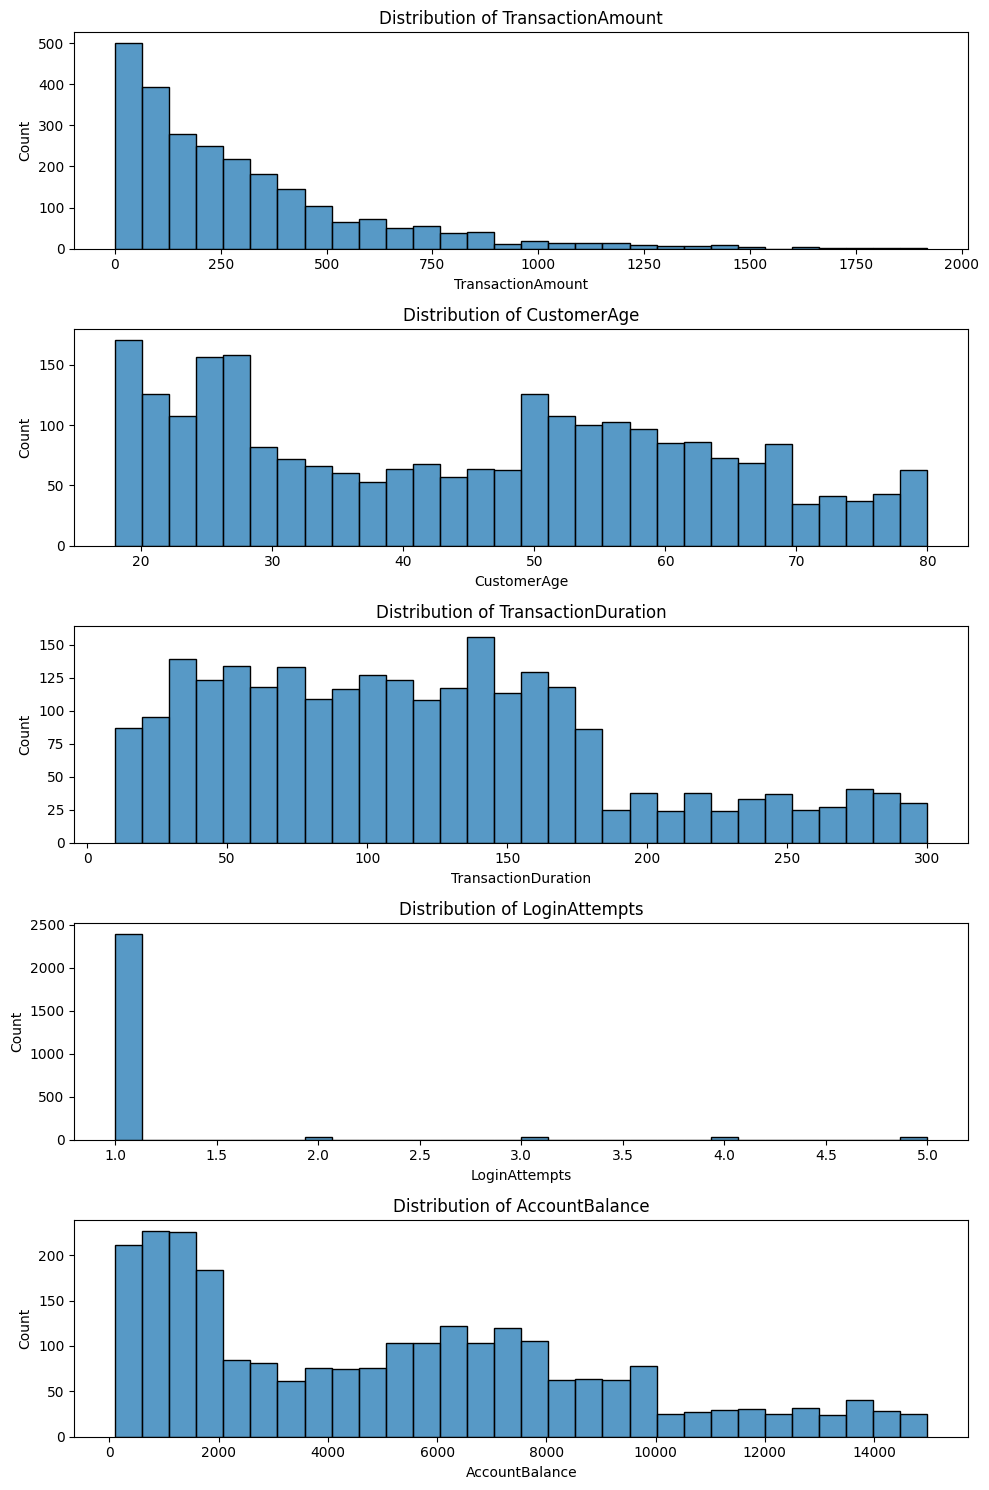

In [100]:
fig, axes = plt.subplots(
    nrows=len(numerical_columns),
    ncols=1,
    figsize=(10, 3 * len(numerical_columns)),
    squeeze=False,
)

for index, column in enumerate(numerical_columns):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        ax=axes[index, 0],
    )

    axes[index, 0].set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

#### 2. Distribusi kategorikal

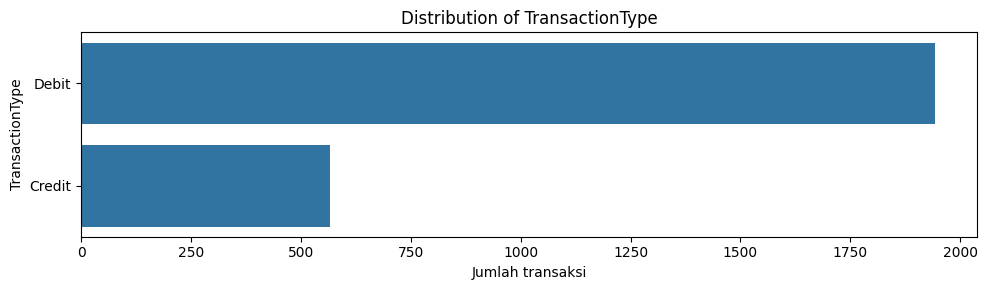

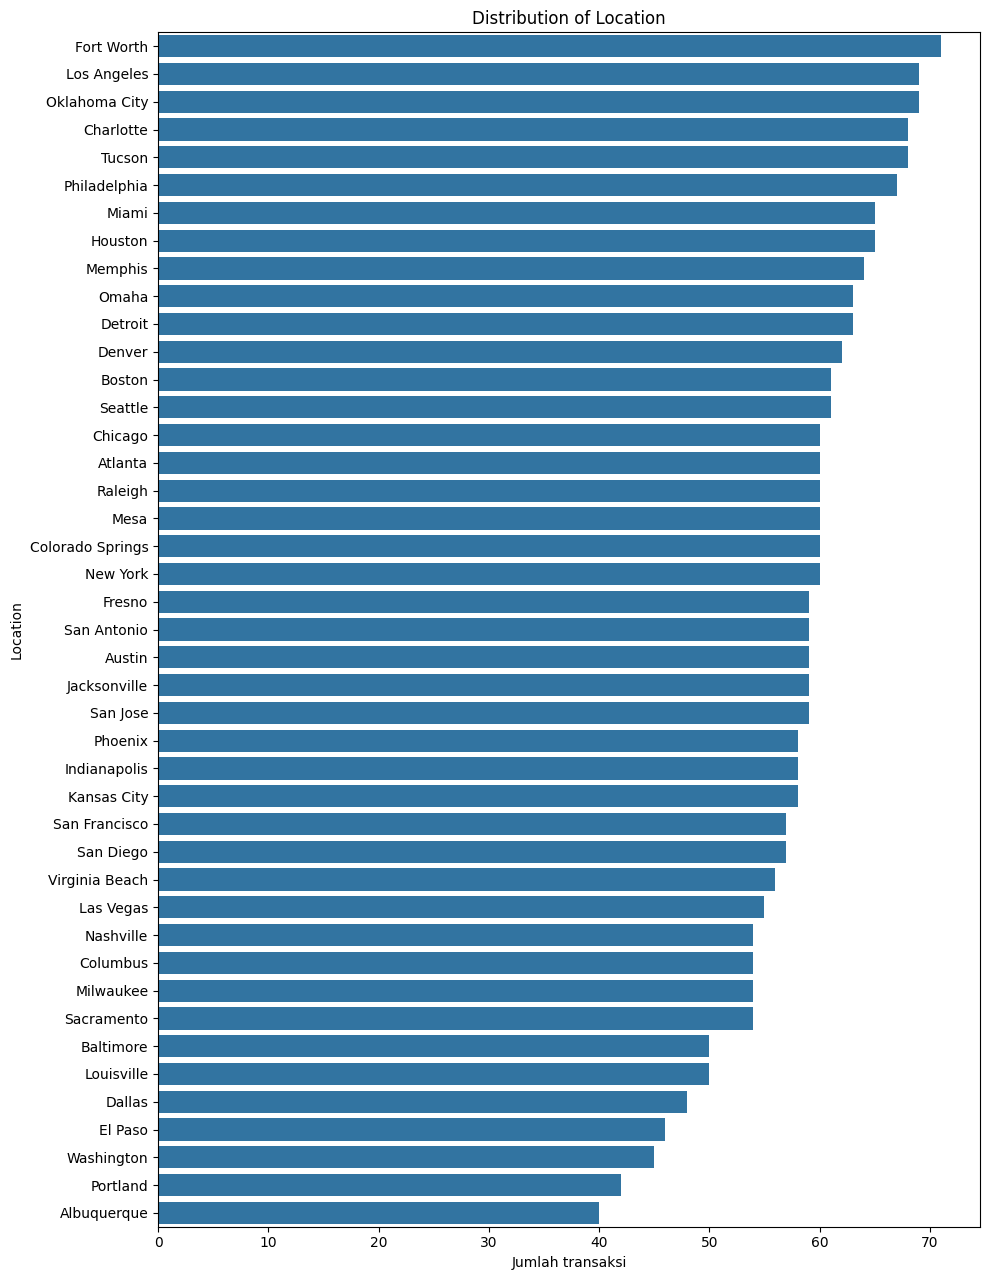

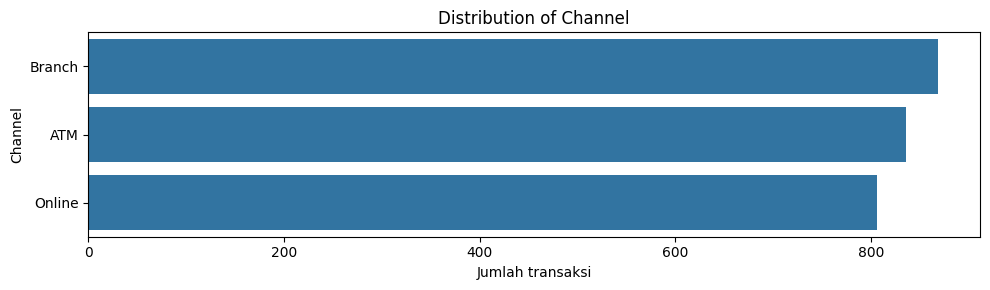

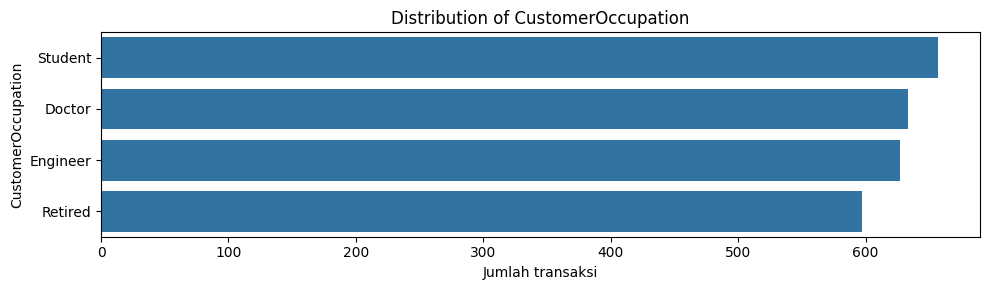

In [101]:
for column in categorical_columns:
    category_count = df[column].nunique()

    fig, ax = plt.subplots(
        figsize=(10, max(3, category_count * 0.3))
    )

    sns.countplot(
        data=df,
        y=column,
        order=df[column].value_counts().index,
        ax=ax,
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel("Jumlah transaksi")

    plt.tight_layout()
    plt.show()

#### 3. Pemeriksaan nilai ekstrem menggunakan boxplot

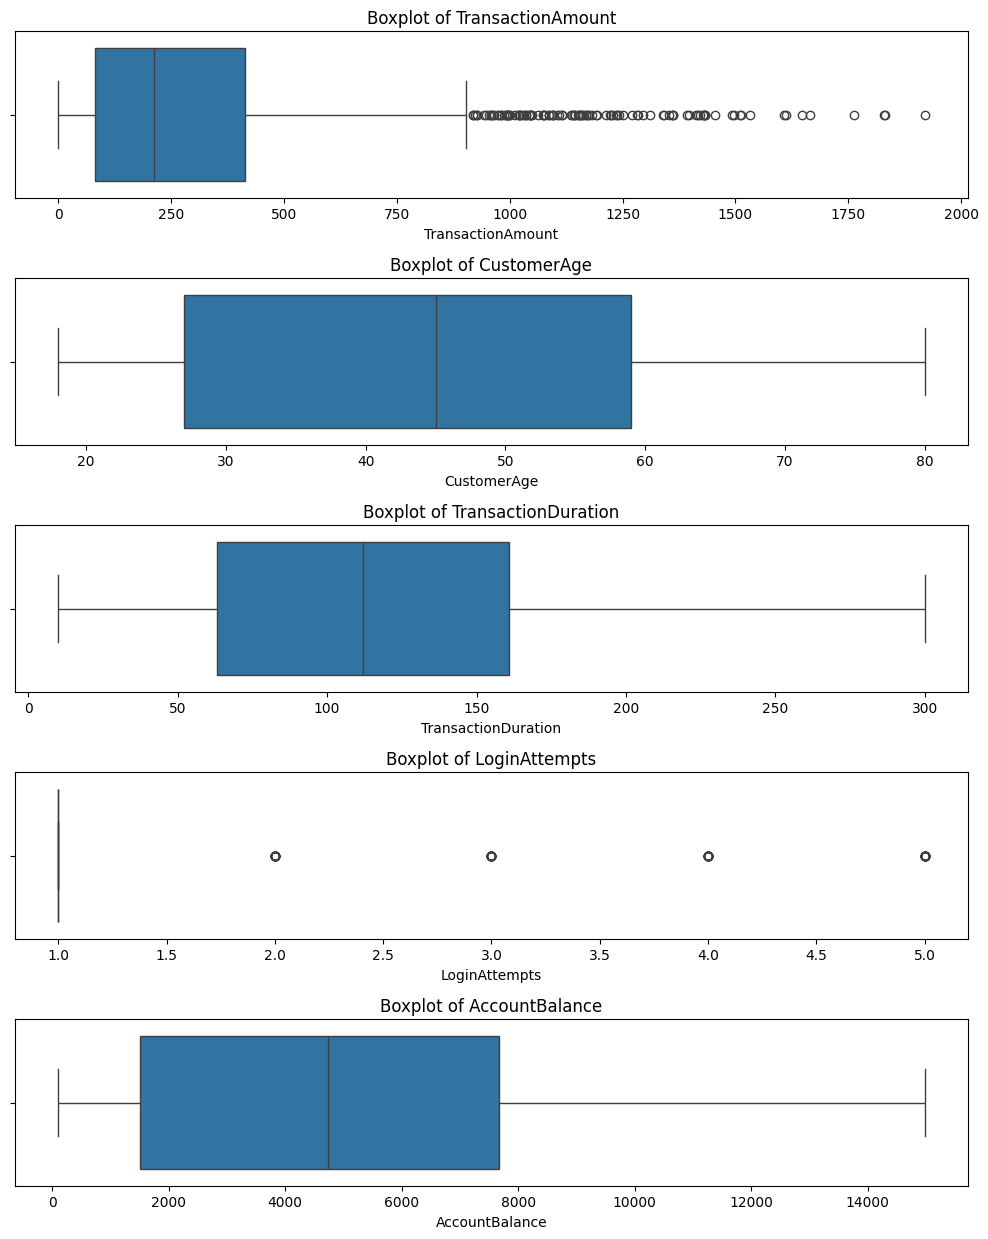

In [102]:
fig, axes = plt.subplots(
    nrows=len(numerical_columns),
    ncols=1,
    figsize=(10, 2.5 * len(numerical_columns)),
    squeeze=False,
)

for index, column in enumerate(numerical_columns):
    sns.boxplot(
        data=df,
        x=column,
        ax=axes[index, 0],
    )

    axes[index, 0].set_title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

#### 4. Korelasi fitur numerik

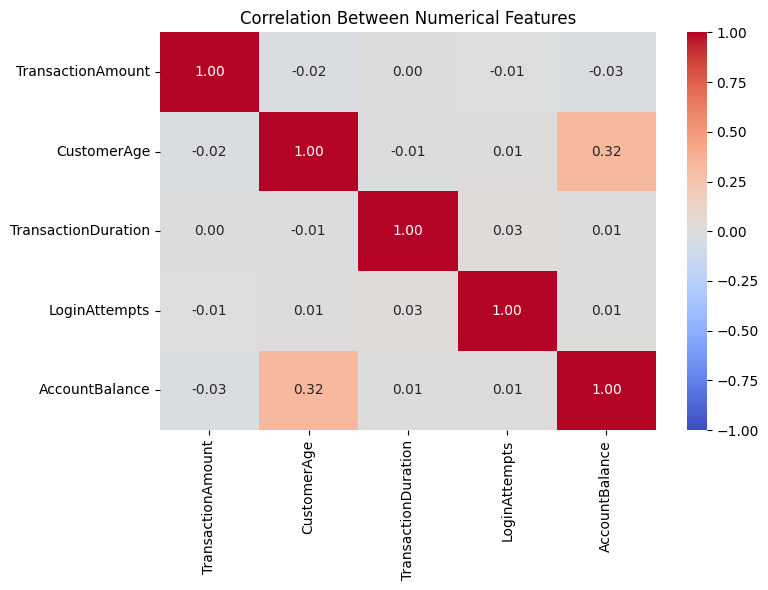

In [103]:
# Korelasi tidak terdefinisi untuk fitur konstan
nonconstant_columns = [
    column
    for column in numerical_columns
    if df[column].nunique() > 1
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[nonconstant_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

#### 5. Nilai transaksi berdasarkan channel

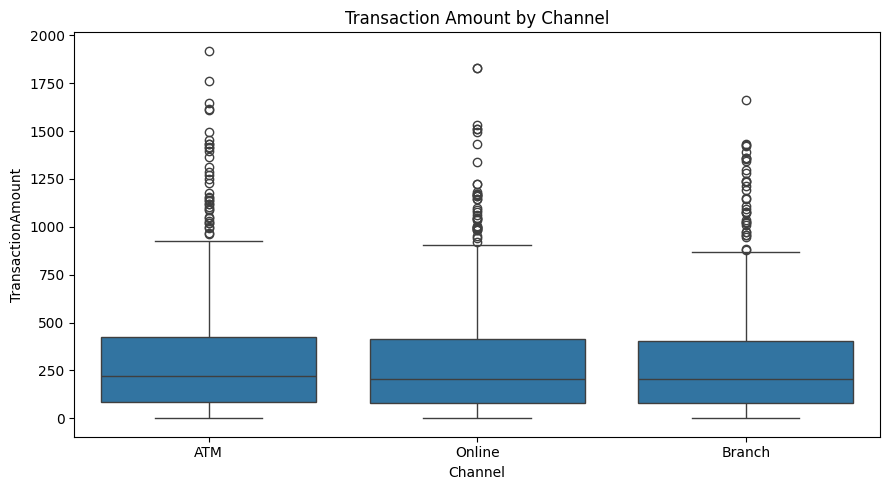

,count,mean,median
Channel,,,
ATM,829,306.584403,218.96
Branch,857,288.449358,204.56
Online,799,296.763504,206.63


In [104]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Channel",
    y="TransactionAmount",
)

plt.title("Transaction Amount by Channel")
plt.tight_layout()
plt.show()

display(
    df.groupby("Channel")["TransactionAmount"]
    .agg(["count", "mean", "median"])
)

## Import Library


In [89]:
!pip install -U scikit-learn

In [90]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [91]:
# Library's version
print("Scikit-learn:", sklearn.__version__)
print("Pandas:", pd.__version__)
print("Joblib:", joblib.__version__)

Scikit-learn: 1.9.1
Pandas: 2.2.3
Joblib: 1.6.0


## Data Understanding

In [60]:
# Load data
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'

In [61]:
df = pd.read_csv(url)
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [62]:
# Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [63]:
# Data Descriptive Statistics
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,2485,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,360
top,TX001748,AC00362,NaN,2023-10-20 17:53:13,Debit,Fort Worth,D000573,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 8:09:17
freq,2,12,NaN,2,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,18
mean,NaN,NaN,297.656468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,NaN
std,NaN,NaN,292.230367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.837359,NaN,70.078513,0.594469,3897.975861,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.310000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,NaN
50%,NaN,NaN,211.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,NaN
75%,NaN,NaN,413.105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,NaN


## Cleaning Data

### Missing

In [64]:
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [65]:
# Handle mising values
df.dropna(inplace=True)
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


### Duplicates

In [66]:
df.duplicated().sum()

np.int64(21)

In [67]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### Categorical

In [68]:
categorical_cols = df.select_dtypes(include='object')
categorical_cols.describe()

,TransactionID,AccountID,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerOccupation,TransactionDate
count,2135,2135,2135,2135,2135,2135,2135,2135,2135,2135,2135
unique,2135,493,2135,2,43,668,586,100,3,4,360
top,TX000592,AC00363,2023-05-15 16:19:14,Debit,Fort Worth,D000451,173.135.78.201,M026,Branch,Student,2024-11-04 8:09:17
freq,1,11,1,1651,62,9,10,43,744,561,15


### Numerical

In [69]:
numerical_cols = df.select_dtypes(include='number')
numerical_cols.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000
mean,298.096178,44.622951,120.152693,1.117564,5093.583789
std,290.962542,17.835201,70.862964,0.578225,3919.681355
min,0.260000,18.000000,10.000000,1.000000,102.200000
25%,83.045000,27.000000,63.000000,1.000000,1482.350000
50%,213.330000,45.000000,113.000000,1.000000,4638.370000
75%,414.630000,59.000000,162.000000,1.000000,7696.920000
max,1831.020000,80.000000,300.000000,5.000000,14977.990000


## Exploratory Data Analysis

### Categorical

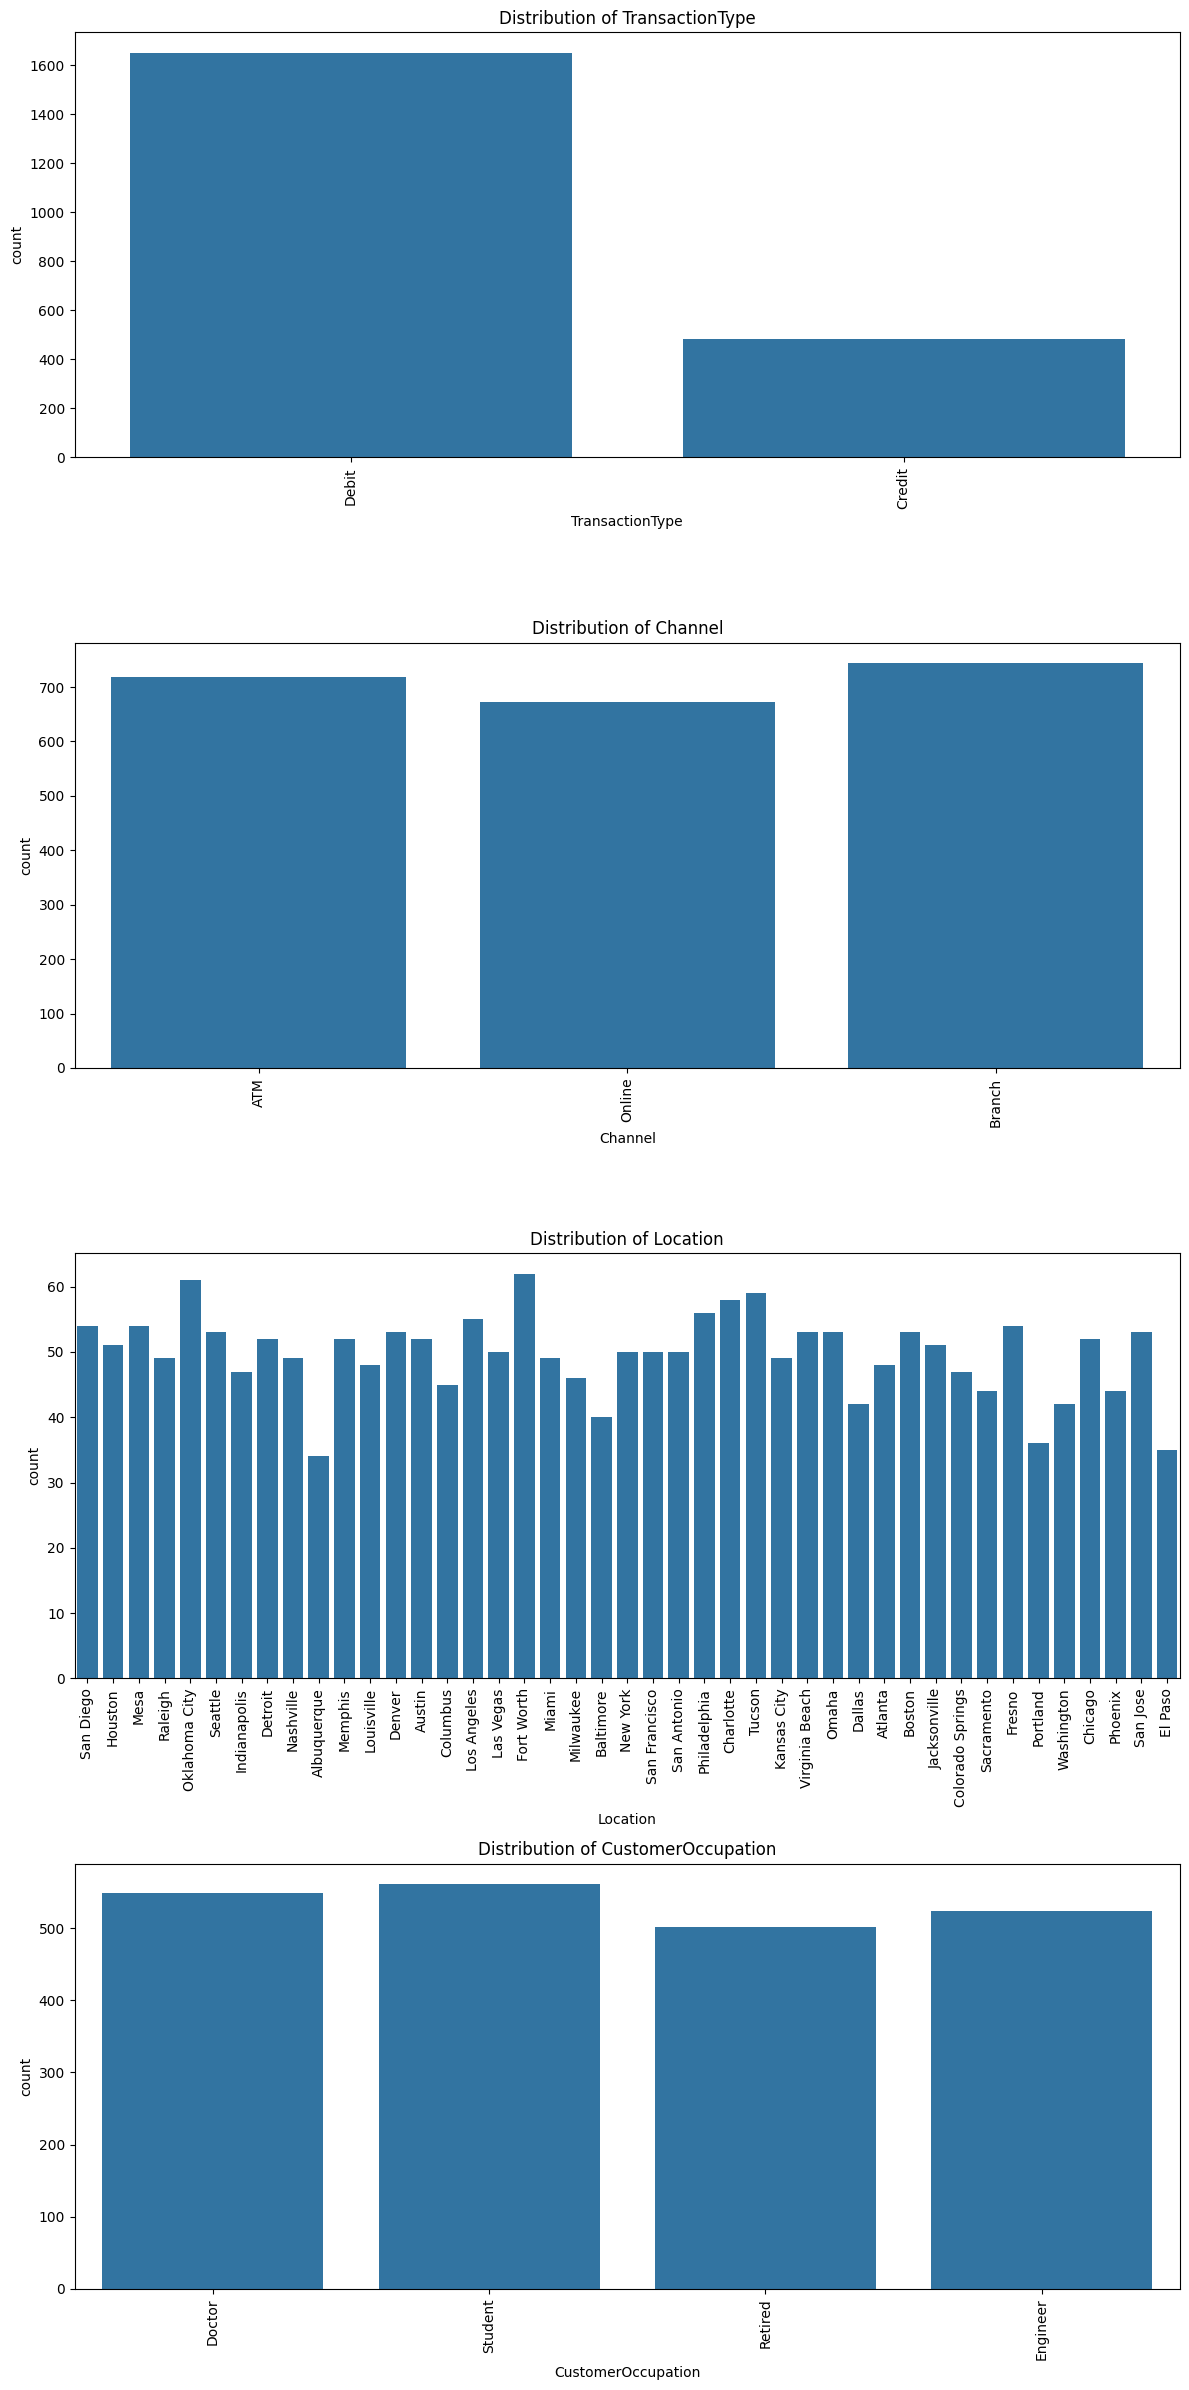

In [70]:
# Distribution Categorical
categorical_cols = [
    'TransactionType',
    'Channel',
    'Location',
    'CustomerOccupation'
    ]

fig, axes = plt.subplots(
    nrows=len(categorical_cols),
    ncols=1,
    figsize=(12, 24),
)

for index, column in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=column,
        ax=axes[index],
    )

    axes[index].set_title(
        f"Distribution of {column}"
    )

    axes[index].tick_params(
        axis="x",
        rotation=90,
    )

plt.tight_layout()
plt.show()

In [71]:
# New Category

col_to_bin = 'CustomerAge'
new_col_name = 'AgeGroupBin'

bin_labels = ['rendah', 'sedang', 'tinggi']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

In [72]:
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,AgeGroupBin
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08,tinggi
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35,tinggi
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04,rendah
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06,rendah
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 8:06:36,rendah


In [73]:
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,AgeGroupBin
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08,tinggi
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35,tinggi
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04,rendah
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06,rendah
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 8:06:36,rendah


### Numerical

In [74]:
numerical_cols = df.select_dtypes(include='number').columns

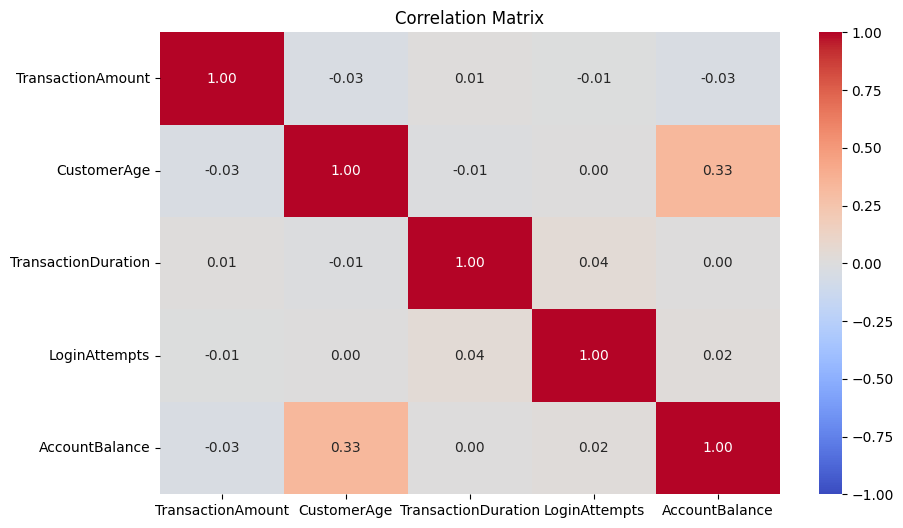

In [75]:
# Correlation
numerical_cols = df.select_dtypes(include=['number']).columns
correlation = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()


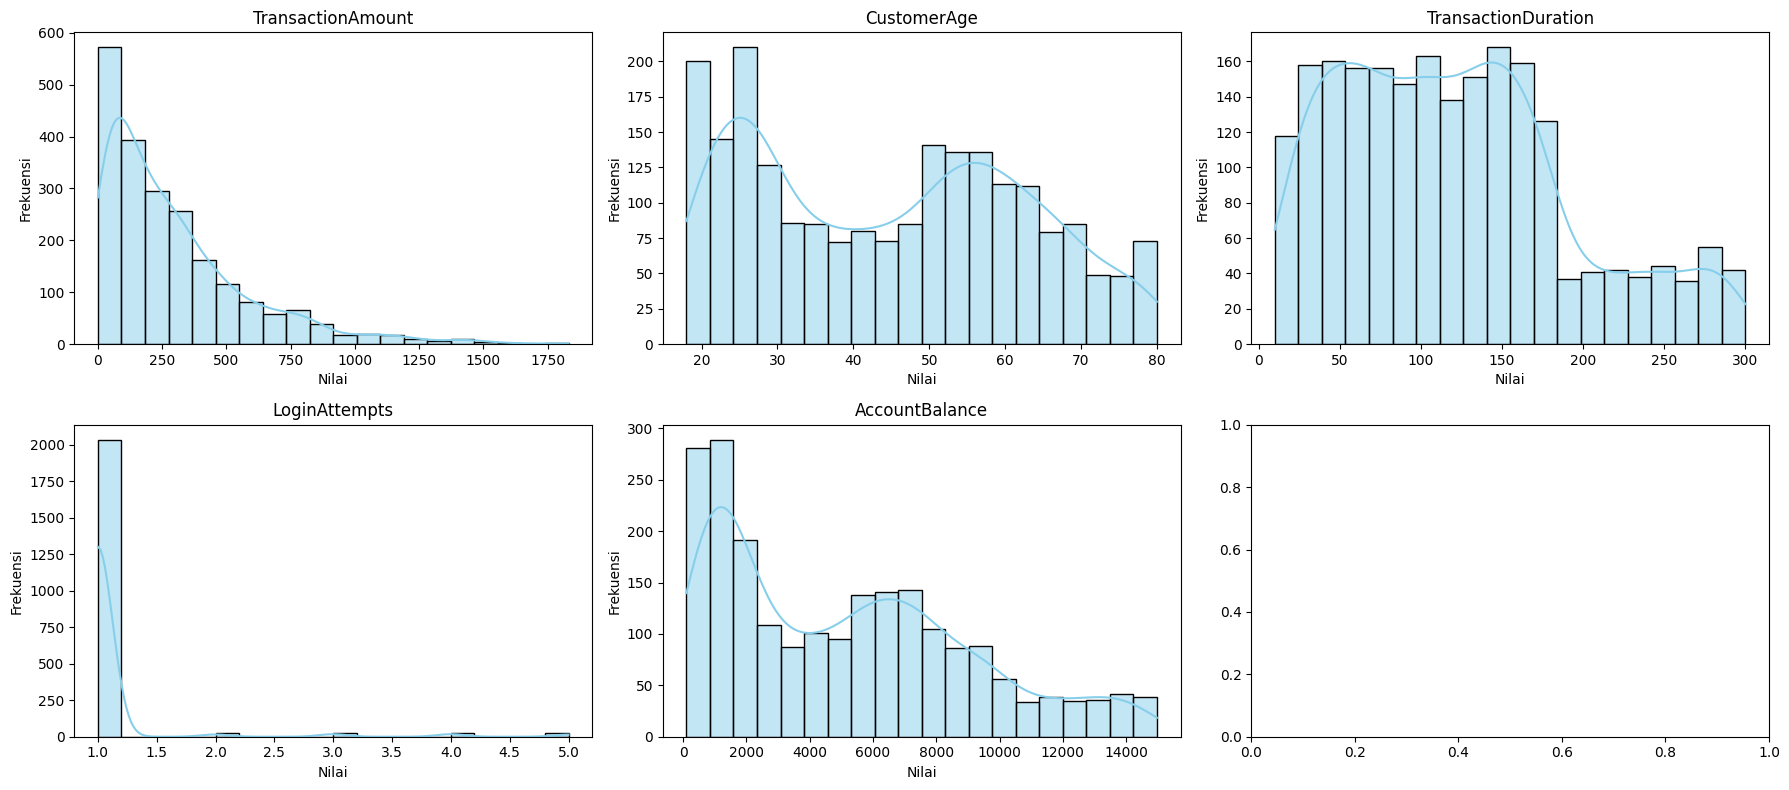

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):


    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax = axes[i])

    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")


plt.tight_layout()
plt.show()

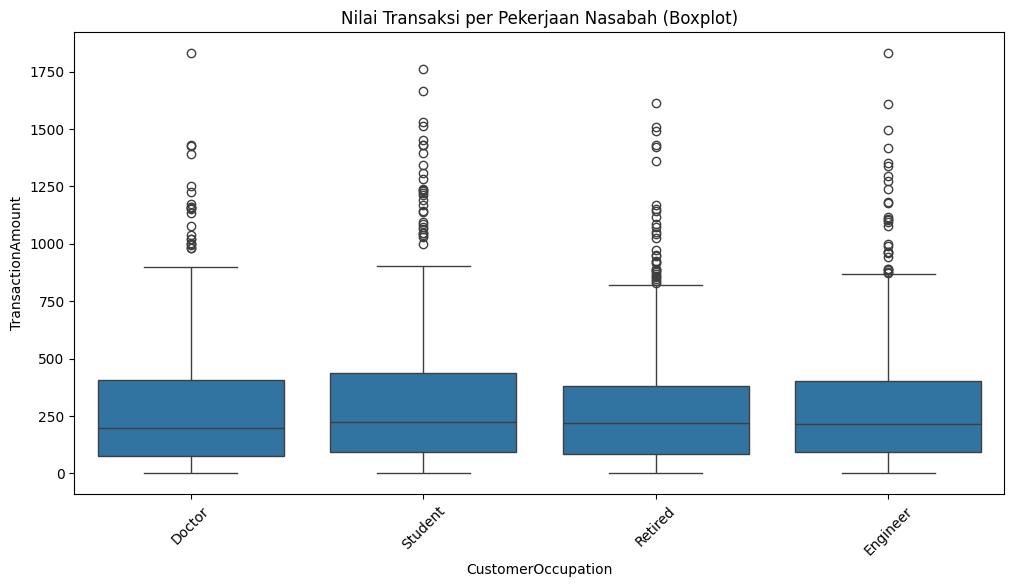

In [77]:
plt.figure(figsize=(12, 6))

sns.boxplot(x="CustomerOccupation", y="TransactionAmount", data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

plt.xticks(rotation=45)

plt.show()

## Preprocessing

### Feature Selections

In [81]:
numerical_columns = [
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "AccountBalance",
]

categorical_columns = [
    "TransactionType",
    "Location",
    "Channel",
    "CustomerOccupation",
    "AgeGroupBin",
]

feature_columns = (
    numerical_columns
    + categorical_columns
)

X_cluster = df[feature_columns].copy()

#### Categorical

In [78]:
cols_to_drop = [col for col in df.columns if
                "id" in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]


df = df.drop(columns=cols_to_drop)

categorical_cols = df.select_dtypes(include='object').columns.tolist()

df[categorical_cols].describe()

,TransactionType,Location,Channel,CustomerOccupation
count,2135,2135,2135,2135
unique,2,43,3,4
top,Debit,Fort Worth,Branch,Student
freq,1651,62,744,561


#### Numerical

In [79]:
# Handling Outlier Data

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroupBin
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,tinggi
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,tinggi
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,rendah
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,rendah
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,rendah


In [80]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
df[numerical_cols].describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,44.693059,119.225193,1.0,5100.811913
std,218.370197,17.743453,70.600647,0.0,3907.153333
min,0.260000,18.000000,10.000000,1.0,102.200000
25%,78.920000,27.000000,63.000000,1.0,1488.650000
50%,199.700000,45.000000,111.000000,1.0,4693.600000
75%,374.500000,59.000000,162.000000,1.0,7659.990000
max,903.190000,80.000000,300.000000,1.0,14977.990000


### Preprocessor

In [82]:
clustering_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_columns,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns,
        ),
    ]
)

## Modelling

In [84]:
clustering_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clustering_preprocessor,
        ),
        (
            "model",
            KMeans(
                n_clusters=2,
                random_state=42,
                n_init=10,
            ),
        ),
    ]
)

In [86]:
print(df["Target"].value_counts())

Target
0    1317
1     628
Name: count, dtype: int64


In [87]:
df["Target"] = (
    clustering_pipeline.fit_predict(
        X_cluster
    )
)

In [88]:
df.groupby("Target")[
    numerical_columns
].mean()

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance
Target,,,,
0,249.506955,54.365224,118.329537,6551.266158
1,272.213041,24.409236,121.103503,2059.015350
